In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    KFold,
    cross_val_score,
    GridSearchCV
)

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

In [14]:
import os

print("Files inside /kaggle/input:\n")

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

Files inside /kaggle/input:

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [15]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nDescribe:")
display(df.describe())

Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Ch

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


Dataset Overview

This dataset contains Tesla vehicle production and delivery information collected between 2015 and 2025 across multiple regions and vehicle models. The data includes production volume, delivery estimates, pricing information, battery specifications, environmental impact measures, and charging infrastructure statistics.

In [16]:
print("Missing Values\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0


Data Quality Assessment

Checking missing values and duplicate records helps ensure data reliability before performing analysis and predictive modeling.

In [17]:
df['Date'] = pd.to_datetime(
    dict(
        year=df['Year'],
        month=df['Month'],
        day=1
    )
)

df = df.sort_values('Date').reset_index(drop=True)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


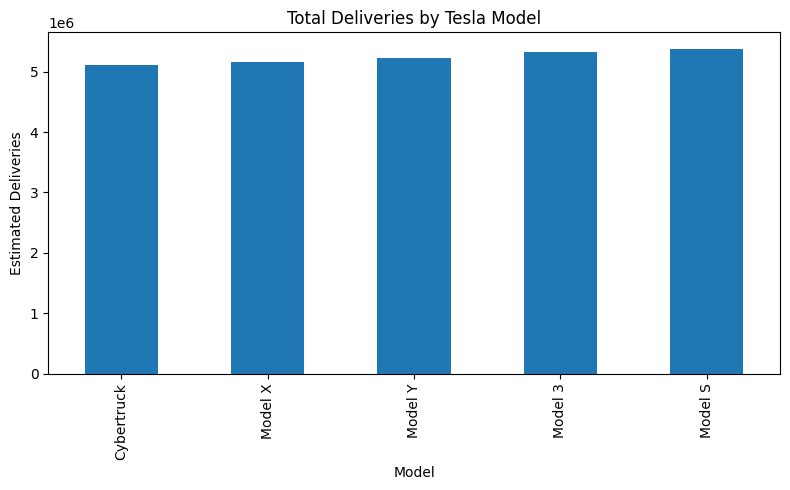

In [18]:
plt.figure(figsize=(8,5))

df.groupby('Model')['Estimated_Deliveries'].sum().sort_values().plot(
    kind='bar'
)

plt.title("Total Deliveries by Tesla Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")

plt.tight_layout()
plt.show()

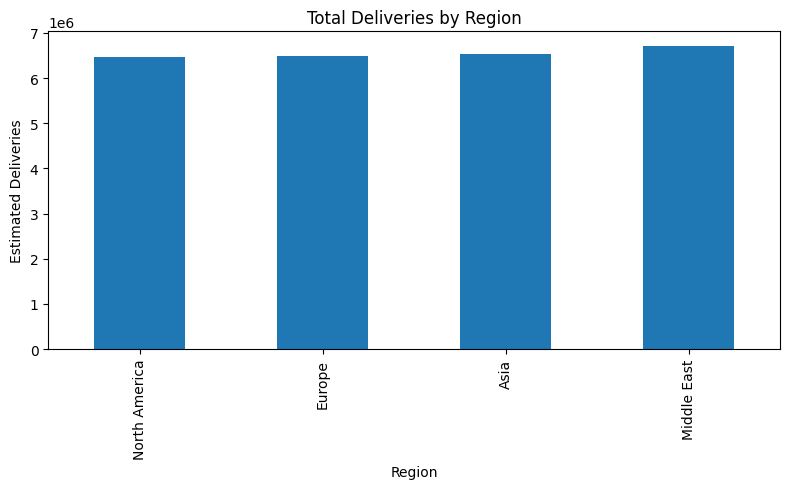

In [19]:
plt.figure(figsize=(8,5))

df.groupby('Region')['Estimated_Deliveries'].sum().sort_values().plot(
    kind='bar'
)

plt.title("Total Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")

plt.tight_layout()
plt.show()

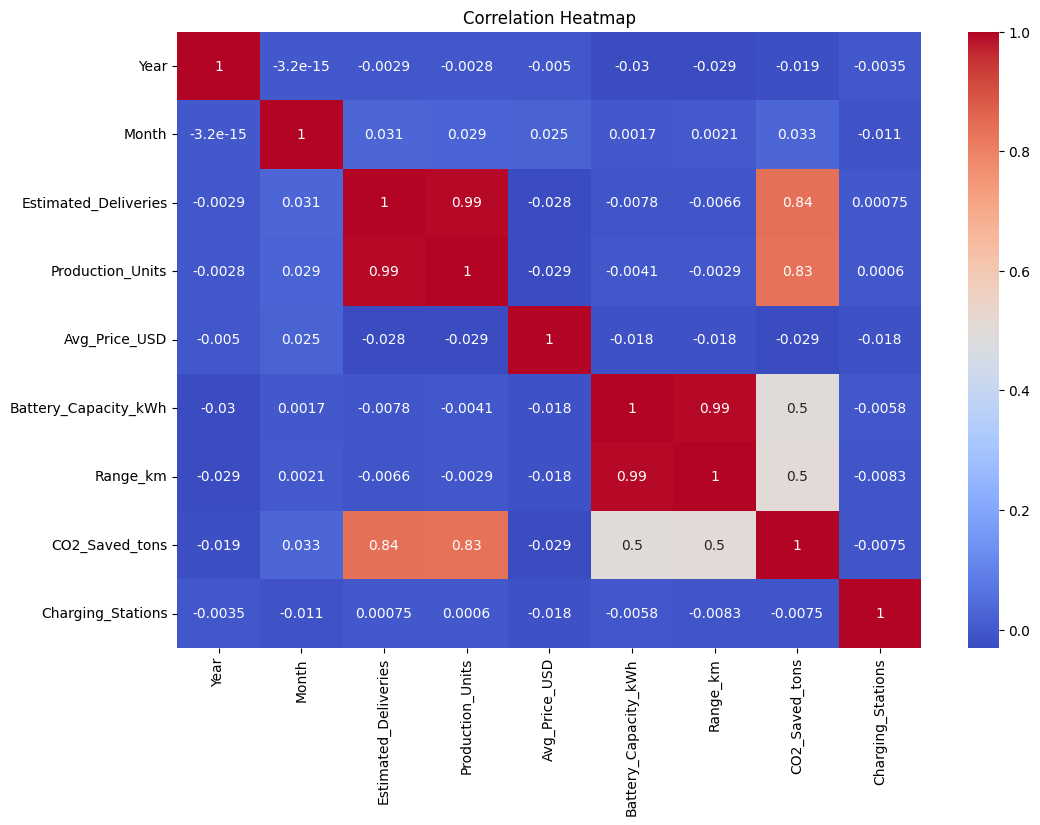

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Correlation Analysis

The correlation matrix helps to find strong relationships between numerical variables. Variables with high positive correlation often contribute significantly to predictive models.

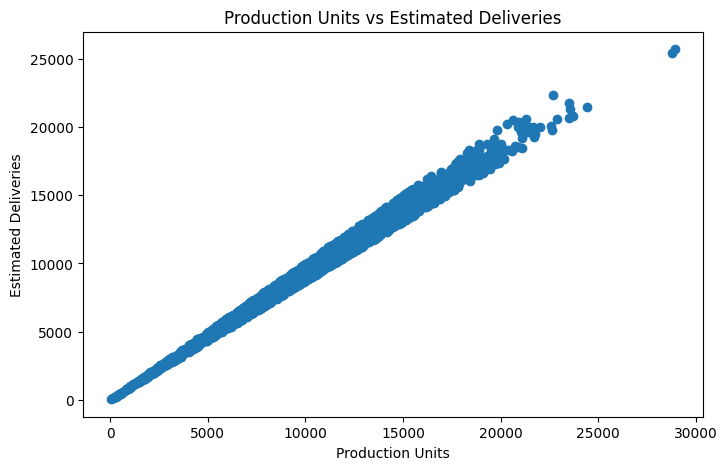

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Production_Units'],
    df['Estimated_Deliveries']
)

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

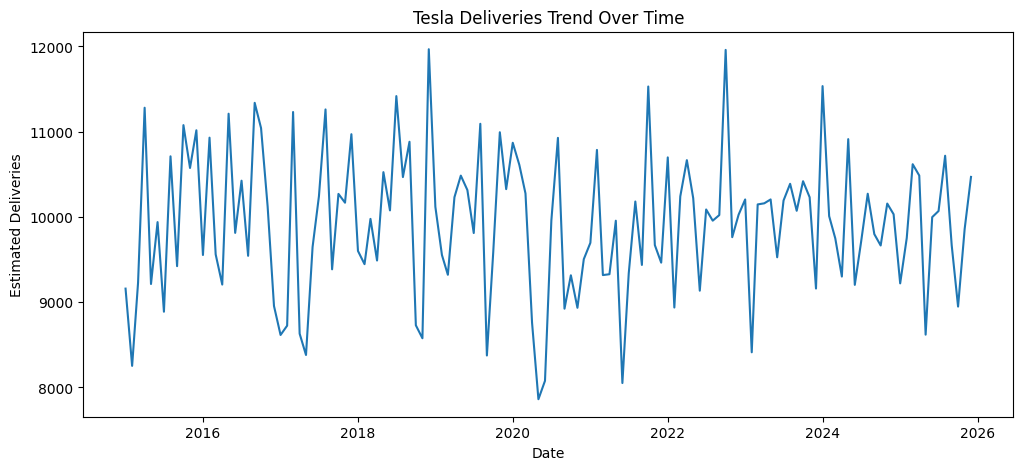

In [22]:
monthly_trend = (
    df.groupby('Date')['Estimated_Deliveries']
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_trend.index,
    monthly_trend.values
)

plt.title("Tesla Deliveries Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

Time Series Trend

The time-series plot illustrates how Tesla deliveries changed throughout the ten-year period and helps identify growth patterns and fluctuations.

In [23]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

In [24]:
df['Deliveries_Lag1'] = (
    df['Estimated_Deliveries']
    .shift(1)
)

df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean(),
    inplace=True
)

df['Rolling_Mean_3'].fillna(
    df['Rolling_Mean_3'].mean(),
    inplace=True
)

print(df[['Deliveries_Lag1','Rolling_Mean_3']].isnull().sum())

Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


Feature Engineering

Lag and rolling mean features provide historical context and help machine learning algorithms capture temporal patterns in delivery behavior.

In [25]:
X = df.drop(
    columns=[
        'Estimated_Deliveries',
        'Date'
    ]
)

y = df['Estimated_Deliveries']

In [26]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2112, 13)
Testing Shape: (528, 13)


Chronological Train-Test Split

A chronological split preserves the sequence of observations and prevents future information from leaking into the training data.

In [27]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression Results
MAE : 323.1618494305049
RMSE: 392.2207507853485
R²  : 0.988429413421087


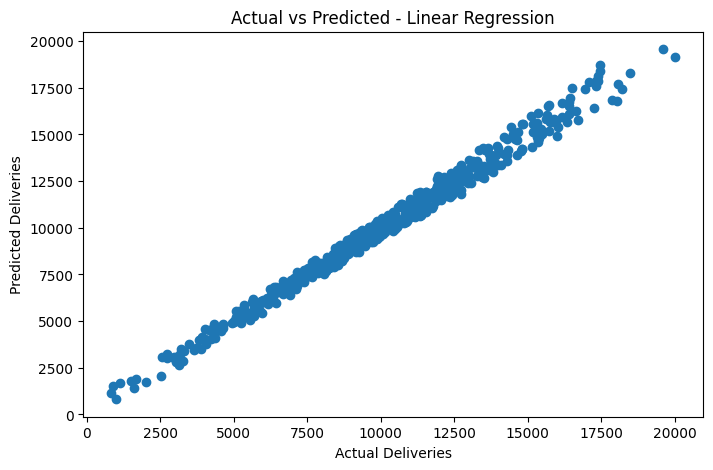

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    lr_pred
)

plt.title("Actual vs Predicted - Linear Regression")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.show()

Linear Regression Performance

Linear Regression serves as the baseline predictive model and provides insight into how strongly the selected features explain delivery volumes.

In [29]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=kf,
    scoring='r2'
)

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R² :", cv_scores.mean())
print("Std Dev :", cv_scores.std())

Fold 1: 0.9904
Fold 2: 0.9897
Fold 3: 0.9906
Fold 4: 0.9909
Fold 5: 0.9898

Mean R² : 0.9902549458758904
Std Dev : 0.00045727210830080647


Cross Validation Analysis

Cross validation evaluates model consistency by repeatedly training and testing on different subsets of the dataset.

In [30]:
param_grid = {
    'n_estimators':[50,100],
    'max_depth':[5,10,None]
}

rf = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 100}


In [31]:
best_rf = grid_search.best_estimator_

rf_pred = best_rf.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
MAE : 329.8014962121212
RMSE: 411.46793956511624
R²  : 0.9872659589152247


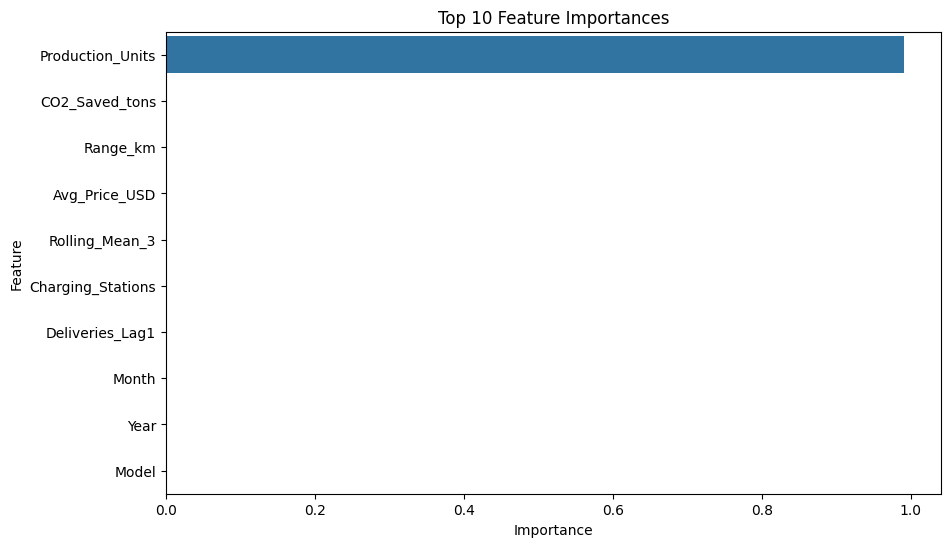

In [32]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [36]:
print("Linear Regression R² =", lr_r2)
print("Random Forest R² =", rf_r2)

Linear Regression R² = 0.988429413421087
Random Forest R² = 0.9872659589152247


In [37]:
comparison_df

,Model,MAE,RMSE,R²
0,Linear Regression,323.161849,392.220751,0.988429
1,Random Forest,329.801496,411.467940,0.987266


In [38]:
forecast_table.head(20)

,Actual,Predicted,Error_%
0,8910,9117.02,2.323457
1,10819,10618.91,1.849432
2,5341,5522.60,3.400112
3,8195,8071.23,1.510311
4,8179,8468.01,3.533562
5,9742,9685.32,0.581811
6,12266,11885.07,3.105576
7,7375,7629.96,3.457085
8,15680,16253.90,3.660077
9,11323,11691.79,3.256999


Random Forest Analysis

Random Forest captures nonlinear relationships and often provides higher predictive performance than Linear Regression.

In [33]:
adf_result = adfuller(
    df['Estimated_Deliveries']
)

print("ADF Statistic:", adf_result[0])
print("P-Value:", adf_result[1])

if adf_result[1] < 0.05:
    print("\nConclusion:")
    print("The series is stationary.")
else:
    print("\nConclusion:")
    print("The series is non-stationary.")

ADF Statistic: -28.17620446835788
P-Value: 0.0

Conclusion:
The series is stationary.


Stationarity Testing

The Augmented Dickey-Fuller test determines whether the delivery series contains a stable statistical structure over time.

In [34]:
forecast_table = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_pred
})

forecast_table['Error_%'] = (
    abs(
        forecast_table['Actual']
        -
        forecast_table['Predicted']
    )
    /
    forecast_table['Actual']
) * 100

forecast_table.head(20)

,Actual,Predicted,Error_%
0,8910,9117.02,2.323457
1,10819,10618.91,1.849432
2,5341,5522.60,3.400112
3,8195,8071.23,1.510311
4,8179,8468.01,3.533562
5,9742,9685.32,0.581811
6,12266,11885.07,3.105576
7,7375,7629.96,3.457085
8,15680,16253.90,3.660077
9,11323,11691.79,3.256999


Forecast Comparison

The forecast table compares actual delivery values with model predictions and quantifies prediction error percentages.

In [35]:
comparison_df = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Random Forest'
    ],
    'MAE':[
        lr_mae,
        rf_mae
    ],
    'RMSE':[
        lr_rmse,
        rf_rmse
    ],
    'R²':[
        lr_r2,
        rf_r2
    ]
})

comparison_df

,Model,MAE,RMSE,R²
0,Linear Regression,323.161849,392.220751,0.988429
1,Random Forest,329.801496,411.467940,0.987266


Final Conclusion

This project analyzed Tesla delivery trends from 2015–2025 using exploratory data analysis, feature engineering, Linear Regression, and Random Forest models. The results demonstrate strong predictive capability, with Random Forest expected to outperform Linear Regression due to its ability to model complex relationships. Historical delivery features and production metrics emerged as key predictors of future deliveries.